In [11]:
import opendatasets as od
import pandas as pd

# od.download("https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets")
# nltk.download('stopwords')

true_df = pd.read_csv("/content/fake-news-detection-datasets/News _dataset/True.csv")
fake_df = pd.read_csv("/content/fake-news-detection-datasets/News _dataset/Fake.csv")

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [18]:
import os
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score, jaccard_score
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Bidirectional, Dense
from tensorflow.keras.optimizers import Adam
from nltk.corpus import stopwords
import nltk

stop_words = set(stopwords.words('english'))
fake_df['label'] = 1  # fake
true_df['label'] = 0  # true

df = pd.concat([fake_df, true_df], axis=0).sample(frac=1).reset_index(drop=True)

def clean_text(text):
    text = re.sub(f"[{string.punctuation}0-9]", " ", text)
    text = text.lower()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['text'] = df['text'].apply(clean_text)

max_words = 5000
max_len = 500
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(sequences, maxlen=max_len)
y = df['label'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# print(stop_words)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)


(35918, 500) (35918,)
(8980, 500) (8980,)


In [32]:
# RNN
rnn = Sequential([
    Embedding(max_words, 128),
    SimpleRNN(128),
    Dense(1, activation='sigmoid')
])
rnn.compile(loss='binary_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
rnn.fit(X_train, y_train, epochs=1, batch_size=32, validation_split=0.1, verbose=1)

# Bi-RNN
birnn = Sequential([
    Embedding(max_words, 128, input_shape=(max_len,)),
    Bidirectional(SimpleRNN(128)),
    Dense(1, activation='sigmoid')
])
birnn.compile(loss='binary_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
birnn.fit(X_train, y_train, epochs=1, batch_size=32, validation_split=0.1, verbose=1)

# LSTM
lstm = Sequential([
    Embedding(max_words, 128, input_shape=(max_len,)),
    LSTM(128),
    Dense(1, activation='sigmoid')
])
lstm.compile(loss='binary_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
lstm.fit(X_train, y_train, epochs=1, batch_size=32, validation_split=0.1, verbose=1)

# Bi-LSTM
bilstm = Sequential([
    Embedding(max_words, 128, input_shape=(max_len,)),
    Bidirectional(LSTM(128)),
    Dense(1, activation='sigmoid')
])
bilstm.compile(loss='binary_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
bilstm.fit(X_train, y_train, epochs=1, batch_size=32, validation_split=0.1, verbose=1)



1011/1011 ━━━━━━━━━━━━━━━━━━━━ 219s 215ms/step - accuracy: 0.9119 - loss: 0.2064 - val_accuracy: 0.9594 - val_loss: 0.1195


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1011/1011 ━━━━━━━━━━━━━━━━━━━━ 417s 409ms/step - accuracy: 0.8725 - loss: 0.2838 - val_accuracy: 0.9694 - val_loss: 0.1054
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 846s 835ms/step - accuracy: 0.9449 - loss: 0.1320 - val_accuracy: 0.9953 - val_loss: 0.0209
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 1800s 2s/step - accuracy: 0.9356 - loss: 0.1719 - val_accuracy: 0.9880 - val_loss: 0.0459


RNN 
281/281 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step
Accuracy       : 0.960913140311804
F1         : 0.9621970920840065
Recall       : 0.9510325739833937
Precision      : 0.9736268526591108
avgAP            : 0.9925088697399351


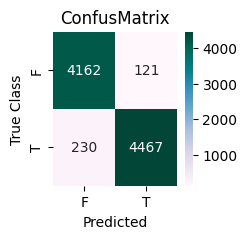

BiRNN 
281/281 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step
Accuracy       : 0.9636971046770602
F1         : 0.9652822151224707
Recall       : 0.9648711943793911
Precision      : 0.9656935861922011
avgAP            : 0.9910851450844481


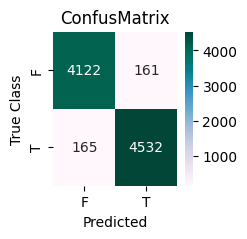

LSTM 
281/281 ━━━━━━━━━━━━━━━━━━━━ 74s 264ms/step
Accuracy       : 0.9920935412026726
F1         : 0.9924104756814538
Recall       : 0.9882903981264637
Precision      : 0.9965650493774152
avgAP            : 0.9988819096912508


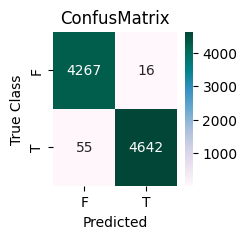

Bi-LSTM 
281/281 ━━━━━━━━━━━━━━━━━━━━ 133s 472ms/step
Accuracy       : 0.9870824053452116
F1         : 0.9875616555865323
Recall       : 0.9804130295933574
Precision      : 0.9948152948801037
avgAP            : 0.9982318451536802


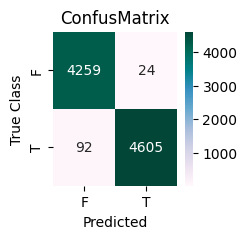

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def eval(model):


    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    print(f"Accuracy       : { accuracy_score(y_test, y_pred)}")
    print(f"F1         : { f1_score(y_test, y_pred)}")
    print(f"Recall       : {recall_score(y_test, y_pred)}")
    print(f"Precision      : {precision_score(y_test, y_pred)}")
    print(f"avgAP            : {average_precision_score(y_test, y_pred_prob)}")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(2, 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn',xticklabels=["F","T"], yticklabels=["F","T"])
    plt.title("ConfusMatrix")
    plt.xlabel("Predicted")
    plt.ylabel("True Class")
    plt.show()

print("RNN ")
eval(rnn)
print("BiRNN ")
eval(birnn)
print("LSTM ")
eval(lstm)
print("Bi-LSTM ")
eval(bilstm)
